# Data exploration of precursors dataset

Loading data into DataFrame

In [406]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

path = "../local/Tvarminne/CIApi_data/MION_NO3_WinterSchool.csv"

df = pd.read_csv(path, engine="pyarrow")
df["Time"] = pd.to_datetime(df["Time"], format="%d-%b-%Y %H:%M:%S", errors='coerce')
df.set_index("Time", inplace=True)

Exploring first few rows of the data

In [419]:
print(df.index.dtype)
print(df.head())

datetime64[us]
                     Reagents  SA  IA  Monomers  NitrogenMonomers  Dimers  \
Time                                                                        
2024-01-01 00:49:36       NaN NaN NaN       NaN               NaN     NaN   
2024-01-01 00:54:00       NaN NaN NaN       NaN               NaN     NaN   
2024-01-01 01:00:00       NaN NaN NaN       NaN               NaN     NaN   
2024-01-01 01:48:00       NaN NaN NaN       NaN               NaN     NaN   
2024-01-01 01:54:00       NaN NaN NaN       NaN               NaN     NaN   

                     NitrogenDimers  TotalOrganics  
Time                                                
2024-01-01 00:49:36             NaN            NaN  
2024-01-01 00:54:00             NaN            NaN  
2024-01-01 01:00:00             NaN            NaN  
2024-01-01 01:48:00             NaN            NaN  
2024-01-01 01:54:00             NaN            NaN  


Exploring basic properties of each column

In [408]:
print(df.describe())

           Reagents            SA            IA      Monomers  \
count  66183.000000  6.618300e+04  6.618300e+04  6.618300e+04   
mean   17506.064321  1.066824e+06  1.148194e+06  1.356784e+07   
std     5684.322021  2.692059e+06  6.068575e+06  1.528804e+07   
min        7.456126  0.000000e+00  0.000000e+00  2.461165e+05   
25%    14119.865000  5.541019e+04  4.067285e+04  4.610562e+06   
50%    17768.450000  1.773352e+05  1.697911e+05  8.750981e+06   
75%    21565.685000  7.979227e+05  8.192583e+05  1.717991e+07   
max    37903.140000  6.544866e+07  5.374306e+08  6.211909e+08   

       NitrogenMonomers        Dimers  NitrogenDimers  TotalOrganics  
count      6.618300e+04  6.618300e+04    6.618300e+04   6.618300e+04  
mean       2.134246e+07  3.614300e+06    9.773323e+05   3.272853e+08  
std        2.431438e+07  7.771448e+07    1.490151e+07   6.627985e+08  
min        0.000000e+00  0.000000e+00    0.000000e+00   2.274554e+07  
25%        4.677180e+06  2.315839e+05    6.582056e+04   1.2

Verifying there are no missing values

In [409]:
print(df.isnull().sum())

Reagents            0
SA                  0
IA                  0
Monomers            0
NitrogenMonomers    0
Dimers              0
NitrogenDimers      0
TotalOrganics       0
dtype: int64


Exploring correlation

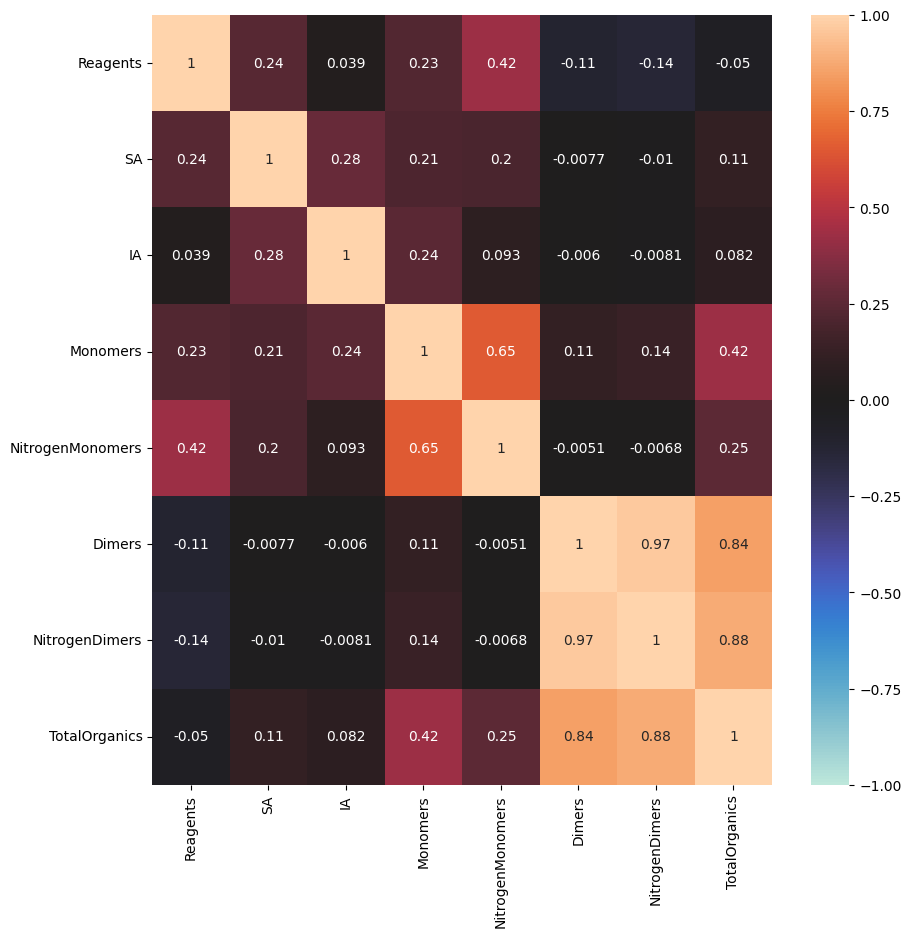

In [410]:
plt.figure(figsize=(10,10))
sns.heatmap(
        df.corr(),
        annot=True,
        vmin=-1, vmax=1, center=0, 
        xticklabels=1, 
        yticklabels=1)
plt.show()

## Outliers

In [411]:
DATA_MAX = {
    "IA": 0.6e8
}

DATA_START = {
    "Reagents": pd.Timestamp("2024-03-01"),
    "SA": pd.Timestamp("2024-03-01"),
    "IA": pd.Timestamp("2024-03-01"),
    "Monomers": pd.Timestamp("2024-03-01"),
    "NitrogenMonomers": pd.Timestamp("2024-03-01"),    
    "Dimers": pd.Timestamp("2024-03-01"),
    "NitrogenDimers": pd.Timestamp("2024-03-01"),
    "TotalOrganics": pd.Timestamp("2024-03-01")
}

window = 300
threshold = 3

for col in df.columns:
    start_time = DATA_START.get(col, None)
    if start_time is not None:
        df.loc[df.index < start_time, col] = pd.NA

    max_value = DATA_MAX.get(col, None)
    if max_value is not None:
        df[col] = df[col].clip(upper=max_value)

    rolling_mean = df[col].rolling(window=window, center=True).mean()
    rolling_std = df[col].rolling(window=window, center=True).std()
    z_score = (df[col] - rolling_mean) / rolling_std
    outliers = z_score.abs() > threshold
    print(f"Column: {col}, Outliers detected: {outliers.sum()}")
    df.loc[outliers, col] = np.nan

Column: Reagents, Outliers detected: 262
Column: SA, Outliers detected: 1355
Column: IA, Outliers detected: 992
Column: Monomers, Outliers detected: 455
Column: NitrogenMonomers, Outliers detected: 477
Column: Dimers, Outliers detected: 1059
Column: NitrogenDimers, Outliers detected: 964
Column: TotalOrganics, Outliers detected: 210


TODO: remove first line, remove outlier in second one to see iodic acid peak in summer

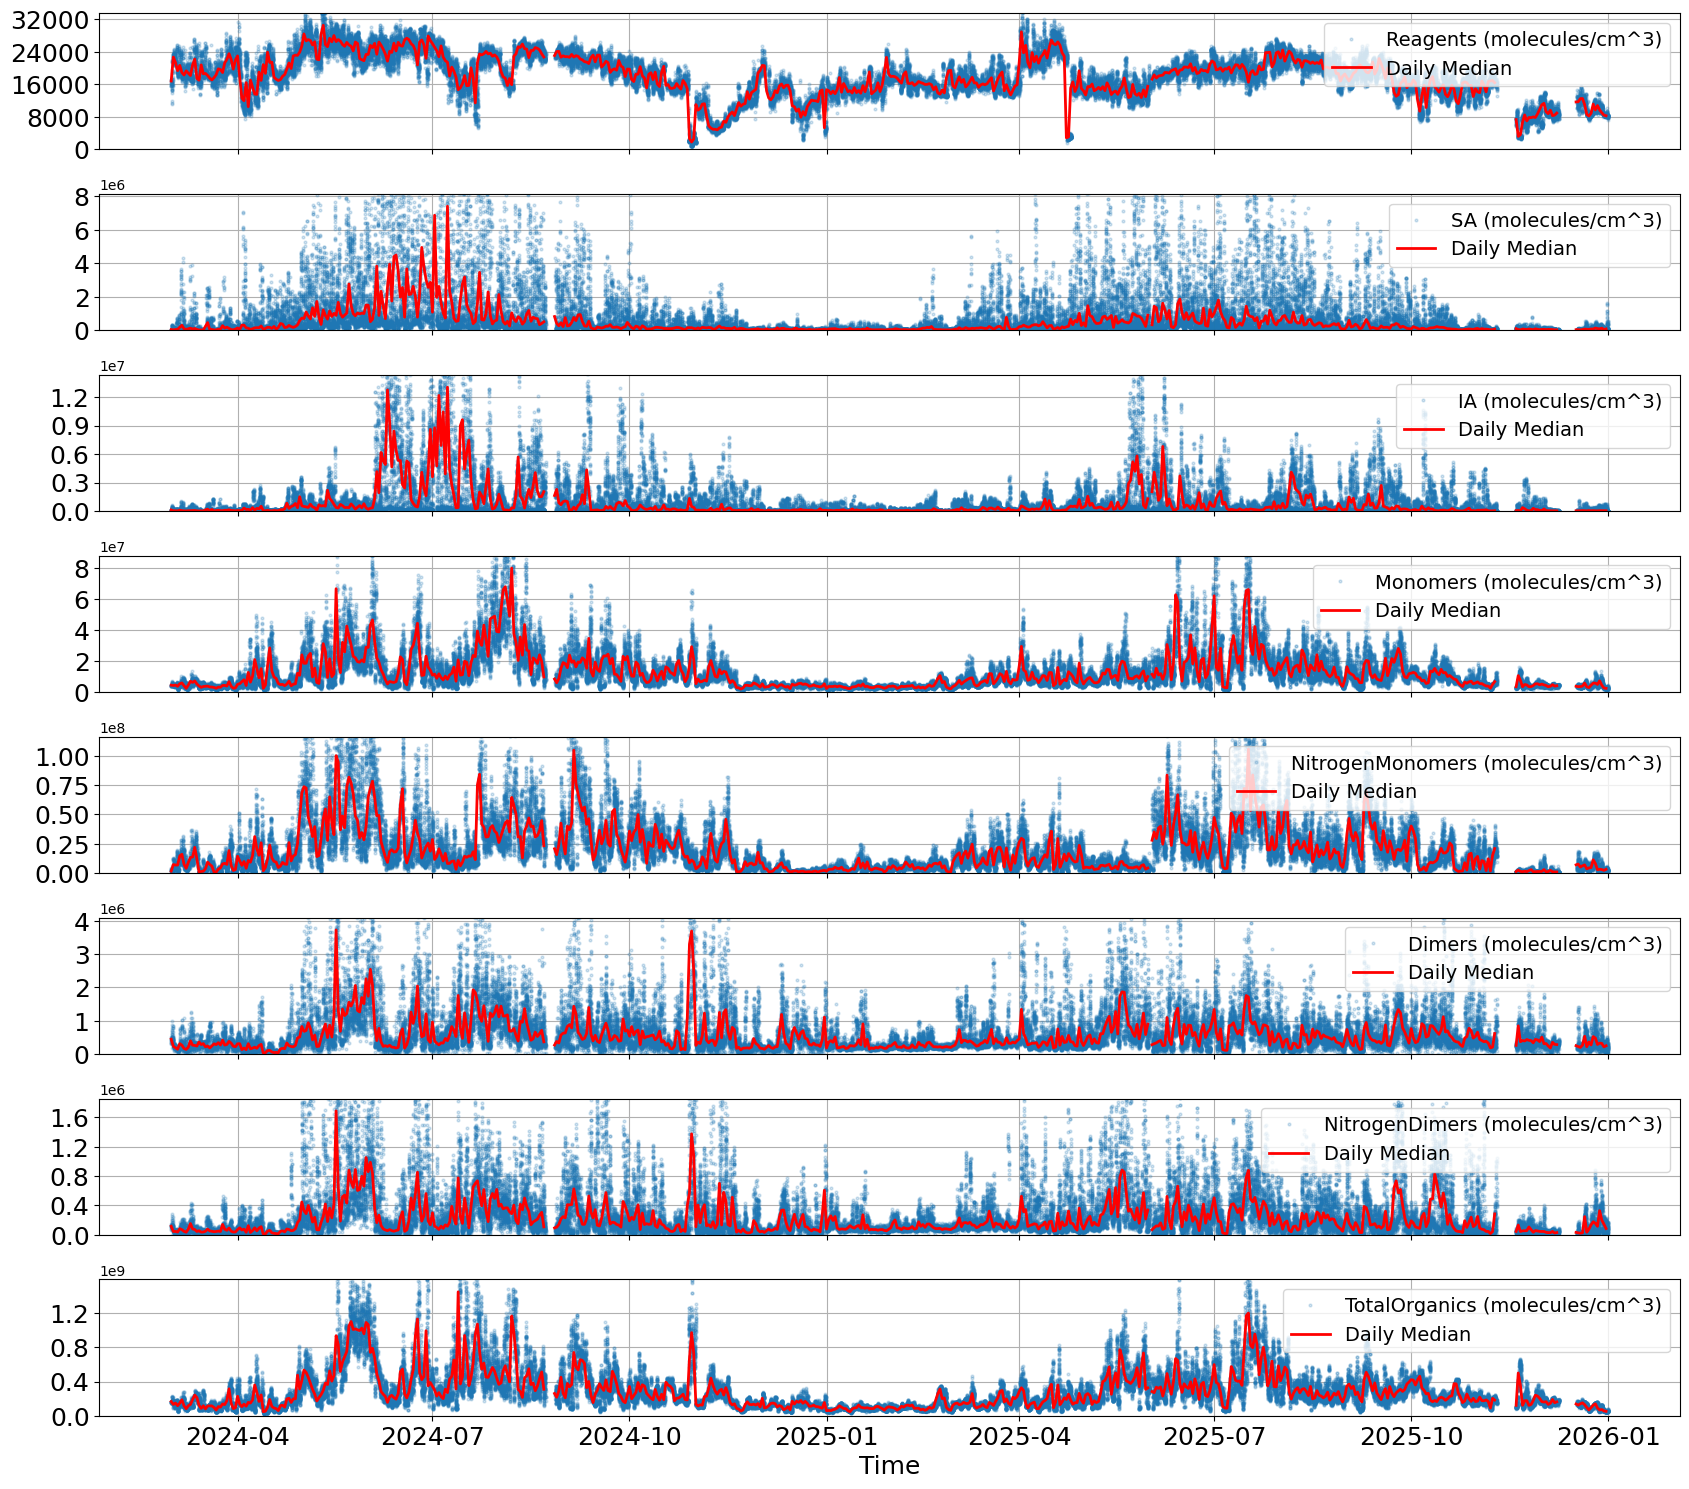

In [ ]:
fig, axes = plt.subplots(
    len(df.columns),
    1,
    figsize=(17, 15),
    sharex=True
)

# fig.suptitle("Precursors")

df_daily = df.resample("D").median()

for idx, value in enumerate(df.columns):
    ax = axes[idx]
    ax.plot(df.index, df[value], label=f"{value} (molecules/cm^3)", marker='o', markersize=2, linestyle='None', alpha=0.2)
    # daily_median = df[value].resample("D").median()
    ax.plot(df_daily.index, df_daily[value],
            marker='o', markersize=0,
            linewidth=2, color="red",
            label="Daily Median")
    
    # ax.set_yscale("log")
    ax.legend(loc="upper right", fontsize=14)
    ax.grid(True)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.set_ylim(0, df_daily[value].max() * 1.1)
    
    ax.tick_params(axis='both', labelsize=18)
    # ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.2f}"))
plt.xlabel("Time", fontsize=18)
plt.tight_layout()
plt.show()

In [417]:
df_hourly = df.resample("h").median()
df_hourly.dropna(inplace=True, how='all')

df_hourly.columns = [f"{col}_moleccm3" for col in df_hourly.columns]
print(df_hourly.head())
df_hourly.to_csv("precursors.csv", index=True, date_format="%Y-%m-%d %H:%M:%S")

                     Reagents_moleccm3  SA_moleccm3  IA_moleccm3  \
Time                                                               
2024-03-01 00:00:00           16154.92    23961.780    104558.50   
2024-03-01 01:00:00           15828.19    19974.945    108532.69   
2024-03-01 02:00:00           15847.42    19037.010     98022.64   
2024-03-01 03:00:00           16757.71    23129.990    106017.70   
2024-03-01 04:00:00           15836.19    35329.730     90602.41   

                     Monomers_moleccm3  NitrogenMonomers_moleccm3  \
Time                                                                
2024-03-01 00:00:00          4205906.0                  2081976.0   
2024-03-01 01:00:00          4336338.5                  1573660.0   
2024-03-01 02:00:00          4130466.0                  2163183.0   
2024-03-01 03:00:00          4024156.0                  3253266.0   
2024-03-01 04:00:00          4417494.0                  1208795.0   

                     Dimers_moleccm3  N